# ECG data processing pipeline

## Analysis plan

**Starting point:** The file `ECGu.txt` contains 6,500 rows and three columns of raw ECG measurements.

**Final goal:** Display the ECG signals with amplitude in millivolts and time in seconds.

The analysis will follow these steps:

1. Import the necessary libraries.
2. Load the raw ECG data.
3. Check the values and dimensions of the data.
4. Plot the raw ECG data.
5. Convert the ECG amplitude into millivolts.
6. Create a time axis in seconds.
7. Plot the rescaled ECG signals.
8. Improve the readability of the code.
9. Create a realistic ECG plot for the optional bonus.

## Load the ECG data

The ECG data must first be loaded into Python so that its values and dimensions can be checked before further analysis.

In [9]:
# Cell 1: imports

# import the necessary libraries for analysis

import numpy as np # NumPy allows for numerical analysis and calculations and its name is shortened to np. 
import matplotlib.pyplot as plt #  The pyplot tool is accessed through Matplotlib and is used to plot/graph the data and is shortened to plt. 

In [10]:
# CELL 2: load the data into a numpy array

# create a variable called data_path to store the path of the data file
data_path = "data/ECGu.txt" #this is the path to locate the data file
raw_ecg_data = np.loadtxt(data_path) # np.loadtxt() loads numerical data from a text file into a NumPy array # https://numpy.org/doc/stable/reference/generated/numpy.loadtxt.html

In [12]:
# Cell 3: look at the data (verify that the data is loaded correctly)

print(raw_ecg_data)
print(raw_ecg_data.shape) #shape tells you the dimensions of the loaded data. 6500 rows = 6,500 recorded samples, 3 columns = three ECG columns/leads: I, II and III.

#  When Python displays the array, it hides most of the rows using ..., so you cannot count them visually. .shape lets you verify that the complete file was loaded correctly.


[[-275. -119. -119.]
 [-275. -119. -119.]
 [-275. -118. -121.]
 ...
 [  -4.  -83.   21.]
 [  -9.  -88.   31.]
 [ -16.  -96.   33.]]
(6500, 3)


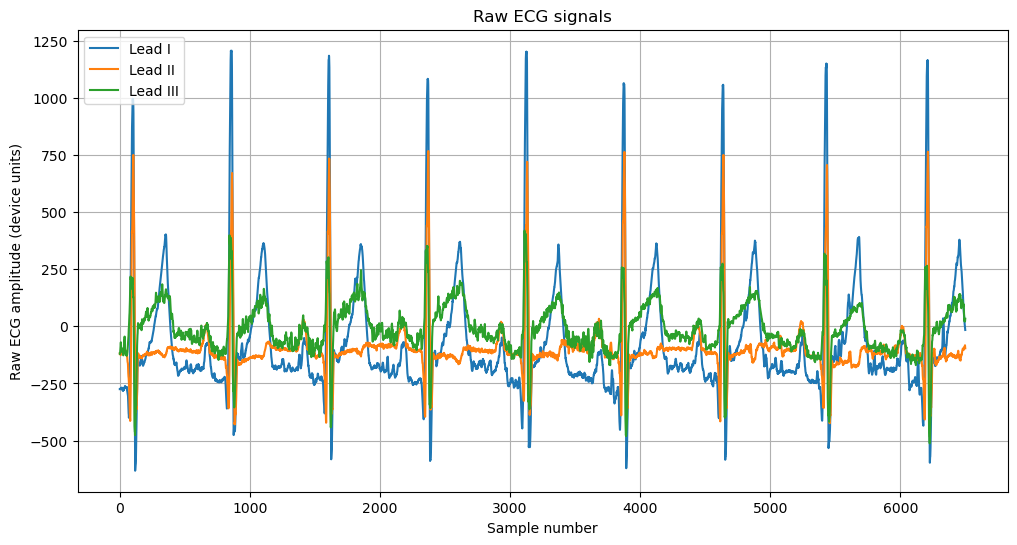

In [ ]:
# Cell 1: Plot the raw ECG data that was loaded in the previous step.

# Resources: 
    # https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html
    # https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.legend.html

# Plot a new figure that is 12 inches wide and 6 inches high.
plt.figure(figsize=(12, 6))

# Plot every row from the 3 coloumns of ECG data. 
plt.plot(raw_ecg_data[:, 0], label="Lead I") # Plot every row in column 0, for representing Lead I. [:, 0] means all rows from the 1st column (Python counts from zero). Label is displayed in the legend.

plt.plot(raw_ecg_data[:, 1], label="Lead II") # Plot every row in column 1, representing Lead II. [:, 1] means all rows from the 2nd column. Label is displayed in the legend.

plt.plot(raw_ecg_data[:, 2], label="Lead III") # Plot every row in column 2, representing Lead III. [:, 2] means all rows from the 3rd column. Label is displayed in the legend.

# create the x-axis and y-axis labels for the graph
plt.xlabel("Sample number")
plt.ylabel("Raw ECG amplitude (device units)")

# create the title, legend, and grid for the graph
plt.title("Raw ECG signals")
plt.legend()
plt.grid()

plt.show() # displays the completed graph

## Checking that the raw ECG plot is correct

The plot appears correct because it shows three lines, corresponding to the three columns in the dataset and the three recorded ECG leads: I, II, and III. The x-axis runs from 0 to 6,499 and is labeled as "Sample number" which is consistent with the 6,500 rows in the data (the 6,500th row is empty in the data set). 

The signals also contain repeating peaks and patterns rather than remaining constant. The y-axis is still expressed in raw device units because the ECG amplitude has not yet been converted into millivolts.

## Convert the ECG amplitude to millivolts

The ECG values are currently expressed in raw device units. According to the A/D converter gain provided in the instructions, 1,024 raw units correspond to 1 millivolt. The raw values must therefore be divided by 1,024.

$ECG_{mV}$ = $ECG_{raw}$ × 1024 $μV$
 

In [14]:
# Store the converter gain: 1,024 raw units correspond to 1 millivolt.
converter_gain = 1024

# Divide every raw ECG value by the gain to convert it to millivolts.
ecg_data_mv = raw_ecg_data / converter_gain # create a new variable called ecg_data_mv to store the answer 

# Display the converted data to check the result.
ecg_data_mv

array([[-0.26855469, -0.11621094, -0.11621094],
       [-0.26855469, -0.11621094, -0.11621094],
       [-0.26855469, -0.11523438, -0.11816406],
       ...,
       [-0.00390625, -0.08105469,  0.02050781],
       [-0.00878906, -0.0859375 ,  0.03027344],
       [-0.015625  , -0.09375   ,  0.03222656]])

# Converting the time axis to seconds

Using the sampling frequency information, we can convert the time axis to seconds:

$timestamp_s$ = $timestamp_{raw}$ / 100

The data file does not contain a time column. However, the sampling frequency is 1,000 Hz, meaning that 1,000 samples were recorded every second. A sample index can therefore be created for every row and divided by 1,000 to calculate its time in seconds

In [15]:
# Store the sampling frequency in hertz (samples per second).
sampling_frequency_hz = 1000 # # A frequency of 1,000 Hz means that 1,000 samples were recorded per second.

# Obtain the number of rows in the ECG dataset.
number_of_samples = raw_ecg_data.shape[0] # raw_ecg_data.shape gives the dimensions of the data (6500, 3). [0] selects the 1st column, meaning the number of rows: 6,500.

# Create a NumPy array of consecutive sample indices.
sample_indices = np.arange(number_of_samples) # np.arange(6500) creates the integers from 0 up to, but not including, 6,500. This creates indices that run from 0 to 6,499.

# Convert each sample index into seconds. 
time_seconds = sample_indices / sampling_frequency_hz # Divide every sample index by the number of samples recorded per second. # For example, index 6499 / 1000 = 6.499 seconds. NumPy performs this division on every value in the sample_indices array.

# Display the first five time values and the final time value.
print(time_seconds[:5]) # [:5] selects the first five values, at indices 0, 1, 2, 3, and 4.
print(time_seconds[-1]) # [-1] selects the final value in the array.

[0.    0.001 0.002 0.003 0.004]
6.499


# Plot the rescaled ECG data

Now that we have the ECG data in the correct units, we can plot it using Matplotlib.

- time_seconds on the x-axis.
- ecg_data_mv on the y-axis.
- All three ECG leads on the same graph.

The ECG signals are now plotted using time in seconds and amplitude in millivolts. This makes the axes easier to interpret and allows the values to be compared with standard ECG measurements.

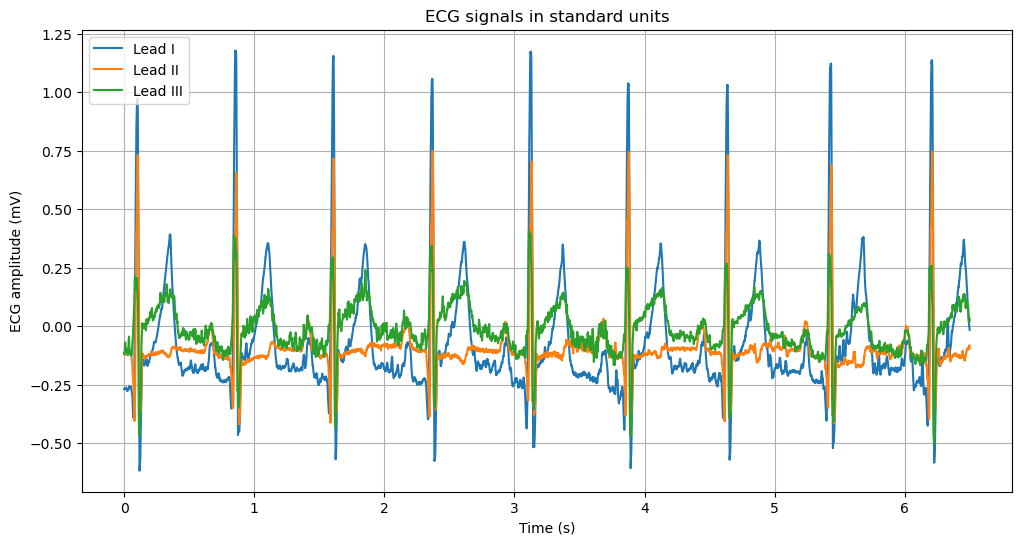

In [ ]:
# Matplotlib plotting resources:
    # https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html

# Create a new figure that is 12 inches wide and 6 inches high.
plt.figure(figsize=(12, 6))

# Plot time against every ecg value that we converted to mv from all 3 ECG column.
plt.plot(time_seconds, ecg_data_mv[:, 0], label="Lead I") # plot the time in seconds (x-value) and ecg data in mV (y-value) for all rows in column 1. label it as Lead I which will appear in the legend.

plt.plot(time_seconds, ecg_data_mv[:, 1], label="Lead II") # plot the time in seconds (x-value) and ecg data in mV (y-value) for all rows in column 2. label it as Lead II which will appear in the legend.

plt.plot(time_seconds, ecg_data_mv[:, 2], label="Lead III") # # plot the time in seconds (x-value) and ecg data in mV (y-value) for all rows in column 3. label it as Lead III which will appear in the legend.


# Label the x-axis and y-axis of the graph
plt.xlabel("Time (s)")

plt.ylabel("ECG amplitude (mV)")

# Add a title above the graph.
plt.title("ECG signals in standard units")

# Display the labels assigned to the three plotted lines.
plt.legend()

# Add grid lines to make the values easier to read.
plt.grid(True)

# Display the completed graph.
plt.show()

## Checking that the raw ECG plot is correct

- The plot contains three time series, corresponding to the three ECG columns and the three recorded leads: I, II, and III.
- Each signal contains 6,500 samples. At a sampling frequency of 1,000 Hz, this represents 6.5 seconds of recording, with timestamps from 0 to 6.499 seconds.
- The amplitudes range approximately from -0.6 mV to 1.2 mV, so they are on the expected millivolt scale for surface ECG signals. However, ECG amplitude varies between leads and between people, so the graph alone cannot confirm that the ECG is clinically normal. You must observe the ECG data for the same person over a period of time and establish a base and see if there are any changes from the base to conclude any abnormal behabiour. 
- Repeated peaks appear at corresponding times across the three leads, and there are no obvious missing sections or constant signals. This supports that the data and time axis were plotted correctly.

References:

- American Heart Association ECG standardization recommendations: https://www.ahajournals.org/doi/10.1161/CIRCULATIONAHA.108.191097
- University of Utah, characteristics of the normal ECG: https://ecg.utah.edu/lesson/3

# Improve readability of the code

The current analysis works, but some plotting commands are repeated and several comments are longer than necessary. The code will be reorganized using descriptive names, concise explanations, and functions that each perform one clear task. This will make the analysis easier to understand, reuse, and modify without changing the results.

- Replacing repeated plotting code with a function.
- Giving variables and functions descriptive names.
- Shortening excessive comments.
- Keeping each function focused on one task.
- Adding Markdown that explains why the code is organized this way.